# Exercise 3: Classification of Airline Tweets with Pretrained Transformers

This notebook fine-tunes a pretrained Transformer model for sentiment classification on the Airline Tweets dataset.

The dataset and preprocessing procedure from Exercise 1 are reused, without performing additional exploratory data analysis.

A pretrained **DistilBERT** model is used to classify tweets into three sentiment categories:

- Negative
- Neutral
- Positive

The workflow includes:

1. Dataset preparation
2. Train, validation and test split
3. Transformer-compatible tokenization
4. Pretrained DistilBERT model loading
5. Fine-tuning
6. Learning curve visualization
7. Test-set evaluation
8. Classification report
9. Confusion matrix
10. Final interpretation and conclusion

In [ ]:
import re
import string
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.optim import AdamW
import torch

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Reproducibility
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 1. Dataset Preparation

The Airline Tweets dataset from Exercise 1 is reused for this exercise.

No additional exploratory data analysis is performed, in accordance with the exercise requirements.

Only the tweet text and sentiment label are retained for the Transformer-based classification task.

In [66]:
df = pd.read_csv("Tweets.csv")

df = df[["text", "airline_sentiment"]].copy()

df = df.dropna()

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (14640, 2)


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


### Text Preprocessing

The same basic text cleaning procedure used in Exercise 1 is retained in order to maintain consistency across the three exercises.

The preprocessing includes:

- Conversion to lowercase
- Removal of URLs
- Removal of user mentions
- Removal of the hashtag symbol while keeping the hashtag word
- Removal of punctuation
- Removal of extra whitespace

The cleaned text is then passed to the pretrained Transformer tokenizer.

Since the selected model is **DistilBERT-base-uncased**, lowercasing is compatible with the pretrained tokenizer. However, removing punctuation may discard some sentiment-related information, since punctuation such as exclamation or question marks can carry useful emotional signal. Retaining more of the original tweet structure could therefore be explored in future experiments.

In [67]:
def clean_text(text):
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove user mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol while keeping the word
    text = re.sub(r"#", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,what said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
2,@VirginAmerica I didn't today... Must mean I n...,i didnt today must mean i need to take another...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it


### Train, Validation and Test Split

The dataset is divided into training, validation and test subsets using stratified sampling.

The split is:

- 70% Training
- 15% Validation
- 15% Test

Stratification preserves the proportion of the three sentiment classes across all subsets.

In [68]:
X = df["clean_text"]
y = df["airline_sentiment"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 10248
Validation samples: 2196
Test samples: 2196


### Label Encoding

The sentiment labels are converted from text categories into numerical class IDs so that they can be used by the Transformer classification model.

In [69]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)
print("Encoded classes:", list(range(len(label_encoder.classes_))))

Classes: ['negative' 'neutral' 'positive']
Encoded classes: [0, 1, 2]


## 2. DistilBERT Tokenization

A pretrained DistilBERT tokenizer is used to convert each tweet into the input representation expected by the Transformer model.

The tokenizer:

- Splits text into subword tokens
- Converts tokens into numerical input IDs
- Adds the special tokens required by DistilBERT
- Creates an attention mask to distinguish real tokens from padding
- Pads or truncates all sequences to a fixed maximum length

A maximum sequence length of 64 tokens is used. Since airline tweets are short-form text, this provides sufficient capacity for most examples while keeping computation efficient.

The slightly larger limit compared with the word-level representation used in Exercise 2 also provides additional room for DistilBERT's subword tokenization, where a single word may be represented by multiple tokens.

In [70]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)

Tokenizer loaded: distilbert-base-uncased
Vocabulary size: 30522


### Tokenization Example

Before creating the complete dataset, one tweet is tokenized in order to inspect the representation generated by DistilBERT.

The tokenizer returns:

- `input_ids`: numerical IDs representing the tokens
- `attention_mask`: values indicating which positions contain real tokens and which positions contain padding

In [71]:
sample_text = X_train.iloc[0]

sample_encoding = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

print("Original tweet:")
print(sample_text)

print("\nInput IDs shape:")
print(sample_encoding["input_ids"].shape)

print("\nAttention mask shape:")
print(sample_encoding["attention_mask"].shape)

print("\nDecoded tokens:")
print(tokenizer.convert_ids_to_tokens(
    sample_encoding["input_ids"][0]
))

Original tweet:
suggestions tell customers approximate wait times when they are on hold 50 min now and allow them to cancelled flight online

Input IDs shape:
torch.Size([1, 64])

Attention mask shape:
torch.Size([1, 64])

Decoded tokens:
['[CLS]', 'suggestions', 'tell', 'customers', 'approximate', 'wait', 'times', 'when', 'they', 'are', 'on', 'hold', '50', 'min', 'now', 'and', 'allow', 'them', 'to', 'cancelled', 'flight', 'online', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


### PyTorch Dataset

A custom PyTorch Dataset is created to tokenize each tweet and return the inputs required by DistilBERT together with the corresponding sentiment label.

Each sample contains:

- Input IDs
- Attention mask
- Encoded sentiment label

In [72]:
class AirlineTweetDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_len
    ):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):

        text = self.texts[index]
        label = self.labels[index]

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(
                label,
                dtype=torch.long
            )
        }

### Dataset and DataLoader Creation

Training, validation and test datasets are created using the DistilBERT tokenizer.

PyTorch DataLoaders are then used to provide the samples to the model in mini-batches during fine-tuning and evaluation.

In [73]:
train_dataset = AirlineTweetDataset(
    X_train,
    y_train_encoded,
    tokenizer,
    MAX_LEN
)

val_dataset = AirlineTweetDataset(
    X_val,
    y_val_encoded,
    tokenizer,
    MAX_LEN
)

test_dataset = AirlineTweetDataset(
    X_test,
    y_test_encoded,
    tokenizer,
    MAX_LEN
)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 641
Validation batches: 138
Test batches: 138


In [74]:
sample_batch = next(iter(train_loader))

print("Input IDs:", sample_batch["input_ids"].shape)
print("Attention Mask:", sample_batch["attention_mask"].shape)
print("Labels:", sample_batch["labels"].shape)

Input IDs: torch.Size([16, 64])
Attention Mask: torch.Size([16, 64])
Labels: torch.Size([16])


## 3. Pretrained DistilBERT Model

A pretrained **DistilBERT** model is used for sequence classification.

DistilBERT is a lighter and faster version of BERT that retains much of its language understanding capability while requiring fewer computational resources.

For this task, the pretrained model is adapted for three-class sentiment classification:

- Negative
- Neutral
- Positive

The classification head is configured with three output labels.

In [75]:
NUM_LABELS = len(label_encoder.classes_)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

print(model)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8272.63it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

### Device Selection

The model is moved to the best available hardware device.

On Apple Silicon systems, PyTorch can use the Metal Performance Shaders (MPS) backend for GPU acceleration. CUDA is used when available, otherwise the model runs on the CPU.

In [76]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = model.to(device)

print("Device:", device)

Device: mps


### Model Sanity Check

Before fine-tuning, a single batch is passed through the model to verify that the input pipeline and model output dimensions are correct.

For a batch of 16 tweets and three sentiment classes, the output logits should have shape `[16, 3]`.

In [77]:
sample_batch = next(iter(train_loader))

input_ids = sample_batch["input_ids"].to(device)
attention_mask = sample_batch["attention_mask"].to(device)
labels = sample_batch["labels"].to(device)

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

print("Input shape:", input_ids.shape)
print("Logits shape:", outputs.logits.shape)
print("Loss:", outputs.loss.item())

Input shape: torch.Size([16, 64])
Logits shape: torch.Size([16, 3])
Loss: 1.0880229473114014


## 4. Fine-Tuning Strategy

The pretrained DistilBERT model is fine-tuned end-to-end on the Airline Tweets dataset.

A small learning rate is used because pretrained Transformer models are sensitive to large parameter updates during fine-tuning.

The training configuration includes:

- AdamW optimizer
- Learning rate: `2e-5`
- Linear learning-rate scheduler with warm-up
- Maximum of 5 epochs
- Early stopping based on validation loss
- Gradient clipping with a maximum norm of `1.0`

Full end-to-end fine-tuning was selected instead of freezing Transformer layers. This allows the pretrained representations to adapt directly to the sentiment classification task, while the small learning rate and learning-rate scheduler help control parameter updates during training.

Freezing or gradually unfreezing Transformer layers could be explored as alternative strategies, particularly when computational resources or the amount of labeled training data are more limited.

In [ ]:
LEARNING_RATE = 2e-5
NUM_EPOCHS = 5
PATIENCE = 2

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

total_training_steps = (
    len(train_loader) * NUM_EPOCHS
)

warmup_steps = int(
    0.1 * total_training_steps
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print("Training steps:", total_training_steps)
print("Warm-up steps:", warmup_steps)

Training steps: 3205
Warm-up steps: 320


### Training and Validation Loop

During each epoch, the model is first fine-tuned on the training set and then evaluated on the validation set.

Training and validation loss are stored for later visualization.

Validation accuracy is also recorded to provide an additional measure of model performance.

Early stopping is applied when the validation loss does not improve for two consecutive epochs. The model state with the lowest validation loss is preserved.

In [79]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
best_model_state = None

epochs_without_improvement = 0


for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for batch in train_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct_train += (
            predictions == labels
        ).sum().item()

        total_train += labels.size(0)


    avg_train_loss = (
        total_train_loss / len(train_loader)
    )

    train_accuracy = (
        correct_train / total_train
    )

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_val_loss += loss.item()

            predictions = torch.argmax(
                logits,
                dim=1
            )

            correct_val += (
                predictions == labels
            ).sum().item()

            total_val += labels.size(0)


    avg_val_loss = (
        total_val_loss / len(val_loader)
    )

    val_accuracy = (
        correct_val / total_val
    )

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


    # -------------------------
    # Early Stopping
    # -------------------------

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping activated "
            f"at epoch {epoch + 1}."
        )

        break

Epoch 01 | Train Loss: 0.6296 | Train Acc: 0.7435 | Val Loss: 0.4585 | Val Acc: 0.8206
Epoch 02 | Train Loss: 0.3716 | Train Acc: 0.8644 | Val Loss: 0.4558 | Val Acc: 0.8256
Epoch 03 | Train Loss: 0.2473 | Train Acc: 0.9178 | Val Loss: 0.5551 | Val Acc: 0.8311
Epoch 04 | Train Loss: 0.1647 | Train Acc: 0.9510 | Val Loss: 0.6610 | Val Acc: 0.8306

Early stopping activated at epoch 4.


In [80]:
model.load_state_dict(best_model_state)

print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)

Best validation loss: 0.4558


### Saving the Best Fine-Tuned Model

The best-performing model state is saved locally after training.

This prevents the computationally expensive fine-tuning process from having to be repeated in future sessions and allows the model to be reloaded directly for evaluation and prediction.

In [81]:
torch.save(
    best_model_state,
    "best_distilbert_airline.pt"
)

print("Best model saved successfully.")

Best model saved successfully.


### Saving the Training History

The recorded training and validation metrics are also saved locally.

This allows the learning curves to be recreated later without repeating the full fine-tuning process.

In [82]:
history = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accuracies": train_accuracies,
    "val_accuracies": val_accuracies
}

torch.save(
    history,
    "training_history.pt"
)

print("Training history saved successfully.")

Training history saved successfully.


## 5. Learning Curves

The training and validation metrics recorded during fine-tuning are visualized to evaluate the learning behaviour of the DistilBERT model.

Both loss and accuracy curves are examined across epochs in order to compare optimization on the training set with generalization performance on the validation set.

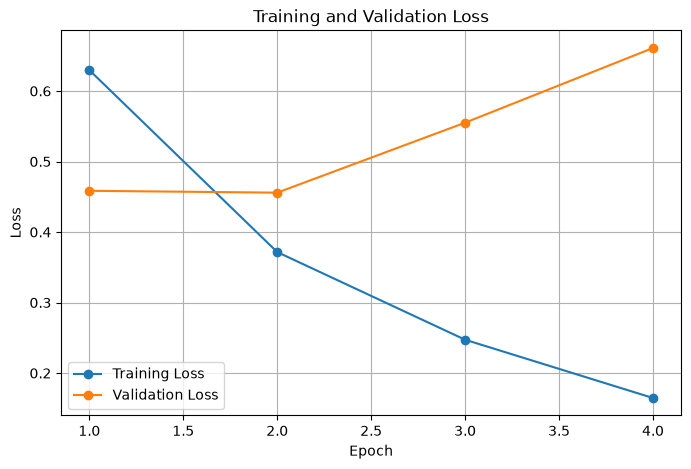

In [83]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Accuracy Curves

Training and validation accuracy are also plotted to complement the loss curves.

The accuracy curves show how classification performance changes during fine-tuning and help identify whether improvements on the training set continue to generalize to the validation set.

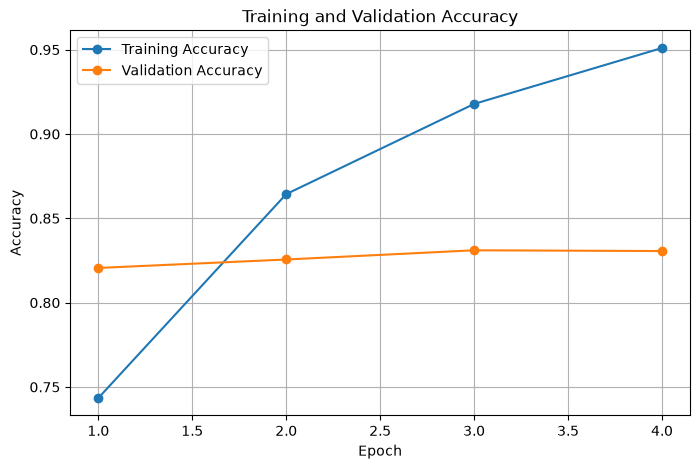

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

### Learning Curve Interpretation

The model improves substantially during the first two epochs.

The minimum validation loss of approximately **0.4558** is reached at epoch 2. After this point, the training loss continues to decrease considerably, while the validation loss begins to increase.

Training accuracy also continues to rise, reaching approximately **95.1%** by epoch 4. In contrast, validation accuracy remains relatively stable at around **82–83%**.

Although validation accuracy reaches its highest value at epoch 3, validation loss has already started to increase. This suggests that the model is becoming increasingly confident on the training data without achieving a meaningful improvement in generalization.

Therefore, the divergence between training and validation performance indicates the beginning of overfitting after epoch 2. Early stopping is activated at epoch 4, and the model parameters corresponding to the lowest validation loss are restored.

## 6. Test Set Evaluation

The best-performing DistilBERT model is evaluated on the independent test set.

The evaluation includes:

- Test loss
- Test accuracy
- Precision, recall and F1-score for each sentiment class
- Confusion matrix

The model state corresponding to the lowest validation loss is used for the final evaluation.

In [85]:
model.eval()

test_loss = 0
all_predictions = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        test_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


avg_test_loss = (
    test_loss / len(test_loader)
)

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.4510
Test Accuracy: 0.8306


### Test Set Performance

The best fine-tuned DistilBERT model achieves a test loss of approximately **0.4510** and a test accuracy of **83.06%**.

The close agreement between validation loss and test loss suggests that the selected model generalizes well to unseen data.

These results confirm that the pretrained Transformer approach provides strong performance on the Airline Tweets sentiment classification task.

### Classification Report

The classification report provides precision, recall and F1-score for each sentiment class.

These metrics provide a more detailed view of model performance than overall accuracy alone, especially when class distributions are imbalanced.

In [86]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    negative       0.88      0.92      0.90      1377
     neutral       0.69      0.67      0.68       465
    positive       0.82      0.70      0.76       354

    accuracy                           0.83      2196
   macro avg       0.80      0.76      0.78      2196
weighted avg       0.83      0.83      0.83      2196



### Classification Report Interpretation

The fine-tuned DistilBERT model achieves an overall test accuracy of approximately **83%**.

Performance differs across the three sentiment classes:

- **Negative sentiment** is classified most effectively, with a precision of **0.88**, recall of **0.92**, and F1-score of **0.90**.
- **Neutral sentiment** remains the most challenging class, with a precision of **0.69**, recall of **0.67**, and F1-score of **0.68**.
- **Positive sentiment** achieves strong performance, with a precision of **0.82**, recall of **0.70**, and F1-score of **0.76**.

The weighted F1-score of **0.83** indicates strong overall classification performance, while the macro F1-score of **0.78** shows that performance remains somewhat uneven across the three sentiment classes.

Overall, the pretrained Transformer model demonstrates strong generalization on the independent test set.

### Confusion Matrix

The confusion matrix compares the true sentiment labels with the predicted labels.

Correct predictions appear on the main diagonal, while off-diagonal values show where the model confuses one sentiment class with another.

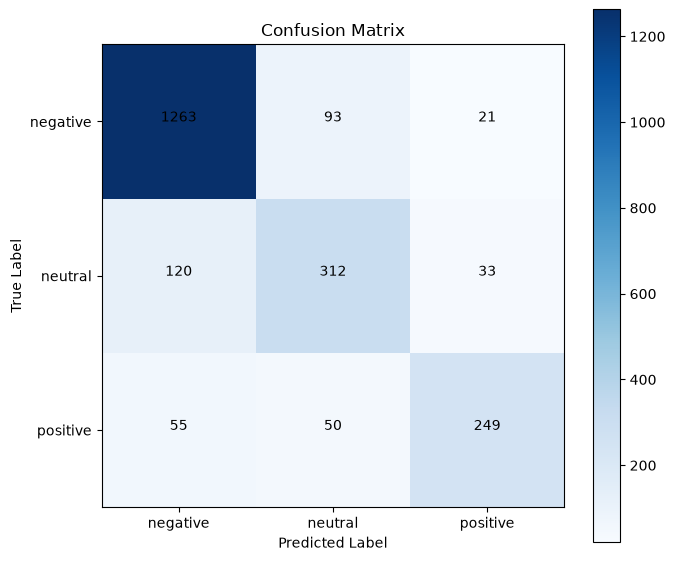

In [87]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 6))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(
    len(label_encoder.classes_)
)

plt.xticks(
    tick_marks,
    label_encoder.classes_
)

plt.yticks(
    tick_marks,
    label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")


for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            horizontalalignment="center"
        )


plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix confirms that the model performs particularly well on negative sentiment.

Out of **1,377 negative tweets**, **1,263** are classified correctly. Most of the remaining negative tweets are misclassified as neutral.

For the neutral class, **312 out of 465 tweets** are correctly classified. Neutral sentiment remains the most difficult class, with a noticeable number of neutral tweets being predicted as negative.

For the positive class, **249 out of 354 tweets** are correctly classified. Most positive misclassifications occur toward the negative and neutral classes.

Overall, the confusion matrix is consistent with the classification report: negative sentiment is the easiest class for the model to identify, while neutral sentiment remains the most challenging.

## 7. Conclusion

In this exercise, a pretrained **DistilBERT** model was fine-tuned for three-class sentiment classification on the Airline Tweets dataset.

The pretrained Transformer tokenizer was used to convert tweets into subword token sequences with attention masks, and the DistilBERT model was adapted with a classification head for the negative, neutral and positive sentiment classes.

The model was fine-tuned end-to-end using the AdamW optimizer, a small learning rate and a linear learning-rate scheduler with warm-up. Early stopping was used to prevent unnecessary training once validation performance stopped improving.

The best validation loss of approximately **0.4558** was reached at epoch 2. After this point, training loss continued to decrease while validation loss increased, indicating the beginning of overfitting.

On the independent test set, the final model achieved a test loss of approximately **0.4510** and a test accuracy of **83.06%**.

The model performed particularly well on negative sentiment, achieving an F1-score of **0.90**. Positive sentiment also showed strong performance with an F1-score of **0.76**, while neutral sentiment remained the most challenging class with an F1-score of **0.68**.

Overall, the experiment demonstrates the effectiveness of pretrained Transformer models for practical NLP classification tasks. Compared with the RNN-based approach developed in Exercise 2, the DistilBERT model achieved higher overall test accuracy and stronger class-level F1-scores, demonstrating the benefit of pretrained contextual language representations for this task.